<a href="https://colab.research.google.com/github/alifanaura/pengolahan-citra-digital/blob/main/Tugas-2/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tugas 2

Nama: Naura Alifa Damayanti
NIM: 25/556087/PA/23338
Mata Kuliah: Pengolahan Citra Digital

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
!pip install numpy opencv-python matplotlib

In [23]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [24]:
dataset_path = "/content/drive/MyDrive/PCD_Assignment02/images"

print(os.listdir(dataset_path))

['low-light-image', 'over-exposed', 'low-contrast', 'blur', 'noisy']


In [25]:
def load_images_from_folder(folder):
    images = []
    filenames = []

    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)

        img = cv2.imread(path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            filenames.append(filename)

    return images, filenames

In [26]:
kategori_list = [
    "low-light-image",
    "over-exposed",
    "low-contrast",
    "blur",
    "noisy"
]

dataset = {}

for kategori in kategori_list:
    folder = os.path.join(dataset_path, kategori)
    images, filenames = load_images_from_folder(folder)

    dataset[kategori] = {
        "images": images,
        "filenames": filenames
    }

print("Dataset dari Google Drive berhasil dimuat!")

Dataset dari Google Drive berhasil dimuat!


In [27]:
def tampilkan_perbandingan(original, hasil, judul_original="Original", judul_hasil="Hasil"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(judul_original)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(hasil)
    plt.title(judul_hasil)
    plt.axis("off")

    plt.show()

In [28]:
def tampilkan_histogram(img, judul="Histogram"):
    plt.figure(figsize=(8, 5))

    if len(img.shape) == 2:
        plt.hist(img.ravel(), bins=256, range=[0, 256])
    else:
        for i, warna in enumerate(["r", "g", "b"]):
            plt.hist(
                img[:, :, i].ravel(),
                bins=256,
                range=[0, 256],
                alpha=0.5,
                label=warna.upper()
            )
        plt.legend()

    plt.title(judul)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Frekuensi")
    plt.show()

In [29]:
for kategori in kategori_list:
    print(kategori, ":", len(dataset[kategori]["images"]), "gambar")

low-light-image : 1 gambar
over-exposed : 1 gambar
low-contrast : 1 gambar
blur : 1 gambar
noisy : 1 gambar


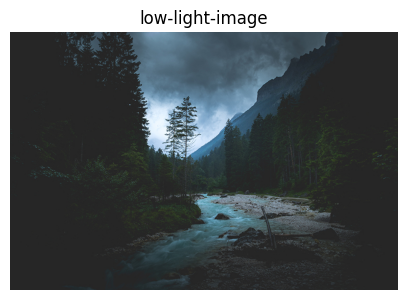

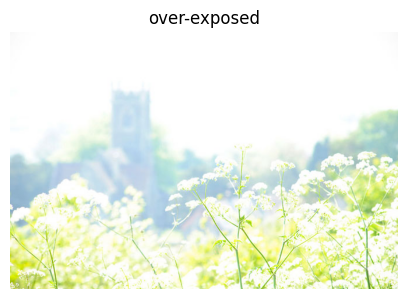

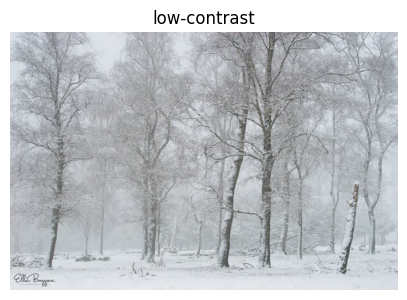

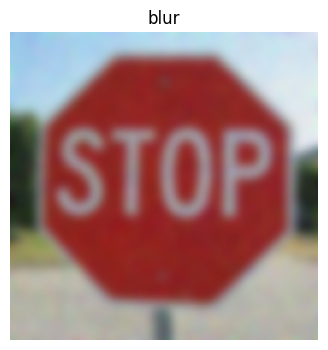

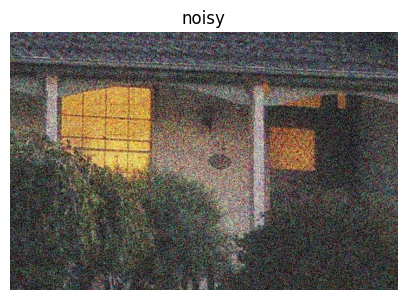

In [30]:
for kategori in kategori_list:
    img = dataset[kategori]["images"][0]

    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.title(kategori)
    plt.axis("off")
    plt.show()

In [31]:
img_low = dataset["low-light-image"]["images"][0]

print("Ukuran gambar:", img_low.shape)

Ukuran gambar: (580, 870, 3)


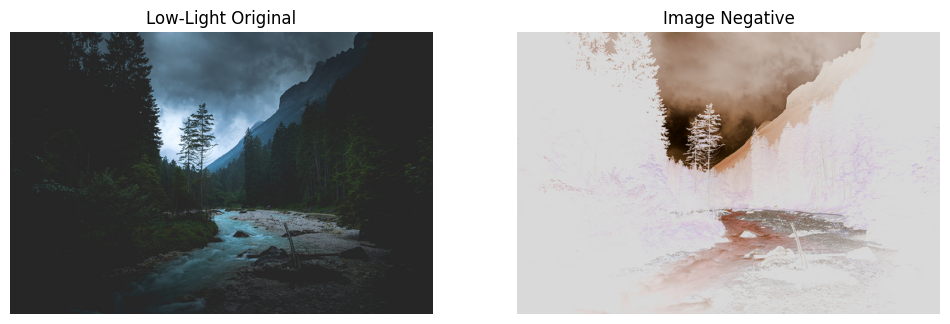

In [32]:
negative_low = 255 - img_low

tampilkan_perbandingan(
    img_low,
    negative_low,
    "Low-Light Original",
    "Image Negative"
)

/tmp/ipykernel_2603/2357835814.py:1: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img_low))
/tmp/ipykernel_2603/2357835814.py:1: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img_low))


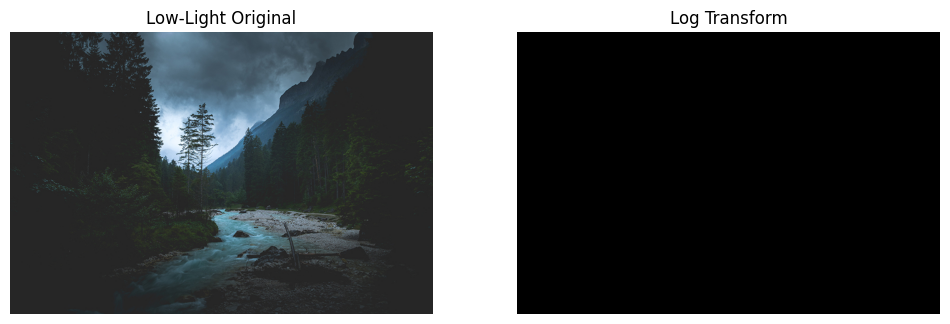

In [33]:
c = 255 / np.log(1 + np.max(img_low))
log_low = c * np.log(1 + img_low.astype(np.float32))
log_low = np.uint8(log_low)

tampilkan_perbandingan(
    img_low,
    log_low,
    "Low-Light Original",
    "Log Transform"
)

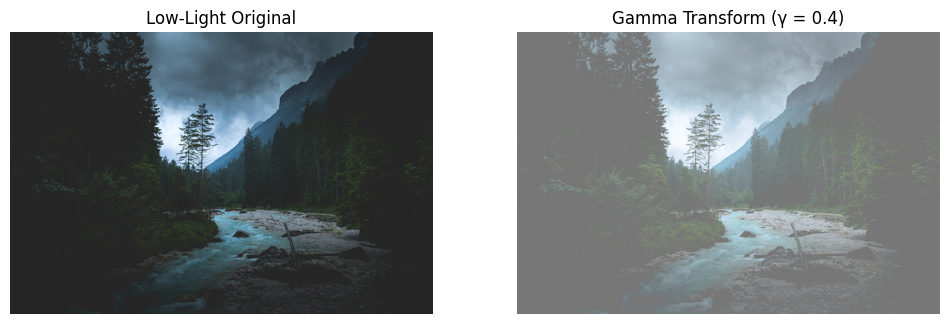

In [34]:
gamma = 0.4

gamma_low = np.array(255 * (img_low / 255) ** gamma, dtype=np.uint8)

tampilkan_perbandingan(
    img_low,
    gamma_low,
    "Low-Light Original",
    "Gamma Transform (γ = 0.4)"
)

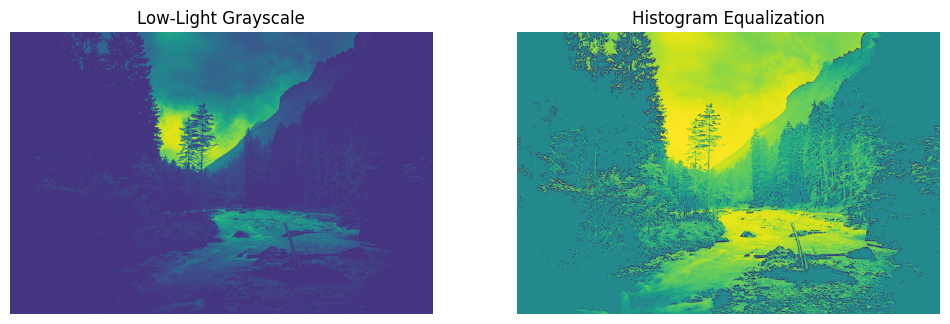

In [35]:
gray_low = cv2.cvtColor(img_low, cv2.COLOR_RGB2GRAY)

equalized_low = cv2.equalizeHist(gray_low)

tampilkan_perbandingan(
    gray_low,
    equalized_low,
    "Low-Light Grayscale",
    "Histogram Equalization"
)

In [36]:
img_over = dataset["over-exposed"]["images"][0]

print("Ukuran gambar:", img_over.shape)

Ukuran gambar: (442, 666, 3)


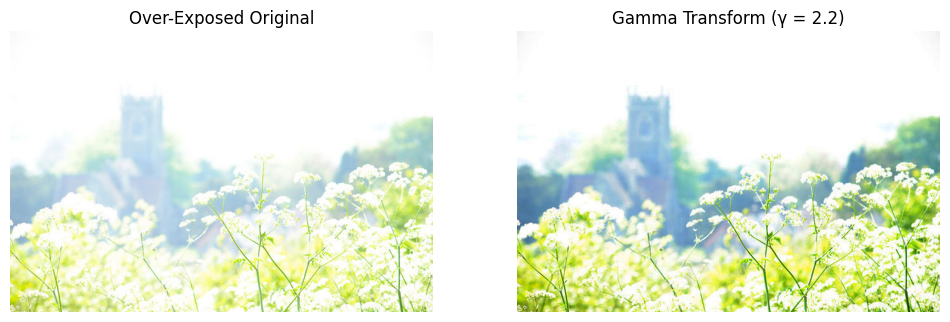

In [37]:
gamma = 2.2

gamma_over = np.array(
    255 * (img_over / 255) ** gamma,
    dtype=np.uint8
)

tampilkan_perbandingan(
    img_over,
    gamma_over,
    "Over-Exposed Original",
    "Gamma Transform (γ = 2.2)"
)

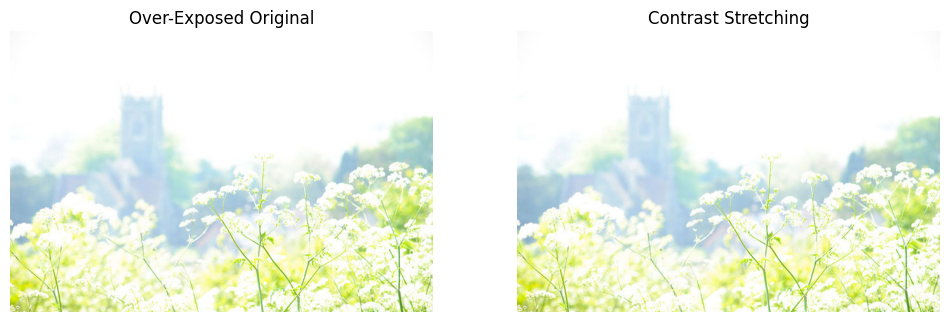

In [38]:
min_val = np.min(img_over)
max_val = np.max(img_over)

contrast_over = ((img_over - min_val) / (max_val - min_val) * 255).astype(np.uint8)

tampilkan_perbandingan(
    img_over,
    contrast_over,
    "Over-Exposed Original",
    "Contrast Stretching"
)

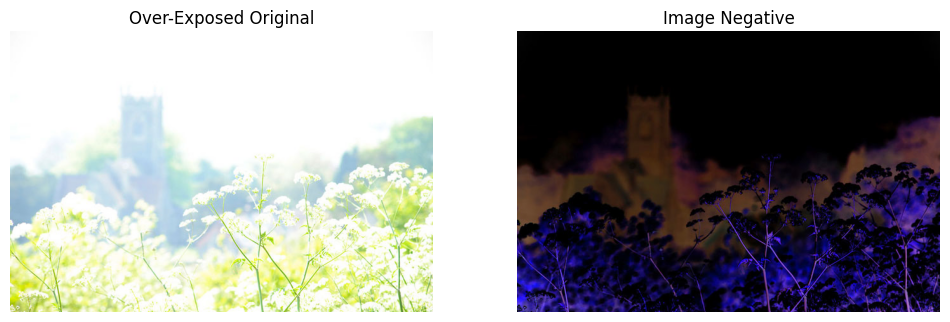

In [39]:
negative_over = 255 - img_over

tampilkan_perbandingan(
    img_over,
    negative_over,
    "Over-Exposed Original",
    "Image Negative"
)

In [40]:
img_contrast = dataset["low-contrast"]["images"][0]

print("Ukuran gambar:", img_contrast.shape)

Ukuran gambar: (532, 800, 3)


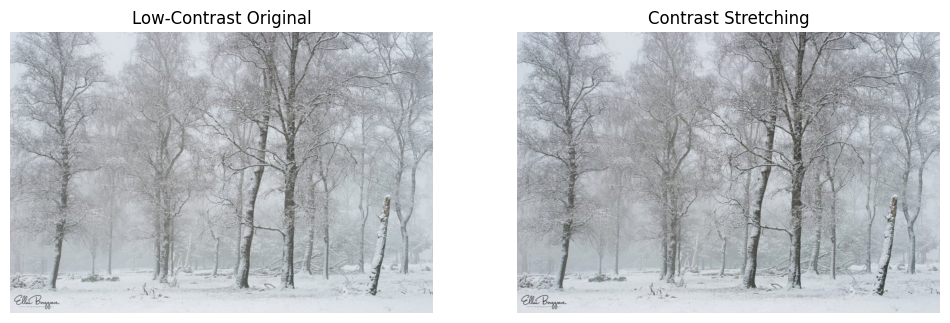

In [41]:
min_val = np.min(img_contrast)
max_val = np.max(img_contrast)

stretch_contrast = (
    (img_contrast - min_val) / (max_val - min_val) * 255
).astype(np.uint8)

tampilkan_perbandingan(
    img_contrast,
    stretch_contrast,
    "Low-Contrast Original",
    "Contrast Stretching"
)

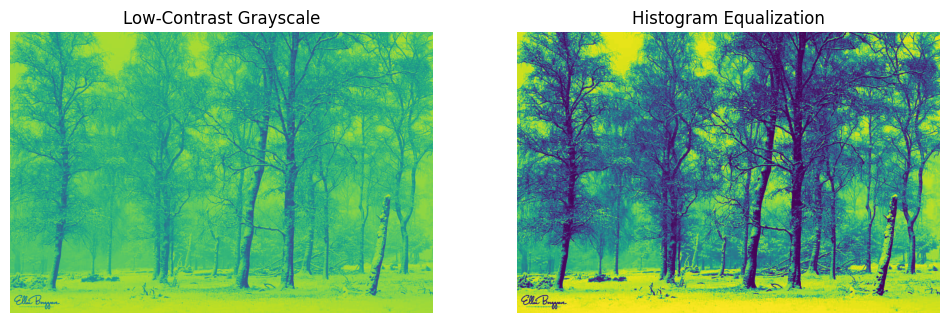

In [42]:
gray_contrast = cv2.cvtColor(img_contrast, cv2.COLOR_RGB2GRAY)

equalized_contrast = cv2.equalizeHist(gray_contrast)

tampilkan_perbandingan(
    gray_contrast,
    equalized_contrast,
    "Low-Contrast Grayscale",
    "Histogram Equalization"
)

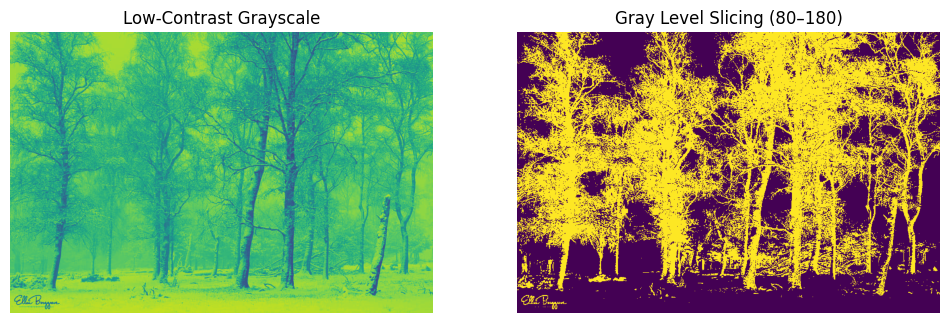

In [43]:
gray_slicing = cv2.cvtColor(img_contrast, cv2.COLOR_RGB2GRAY)

slicing_contrast = np.zeros_like(gray_slicing)

mask = (gray_slicing >= 80) & (gray_slicing <= 180)
slicing_contrast[mask] = 255

tampilkan_perbandingan(
    gray_slicing,
    slicing_contrast,
    "Low-Contrast Grayscale",
    "Gray Level Slicing (80–180)"
)

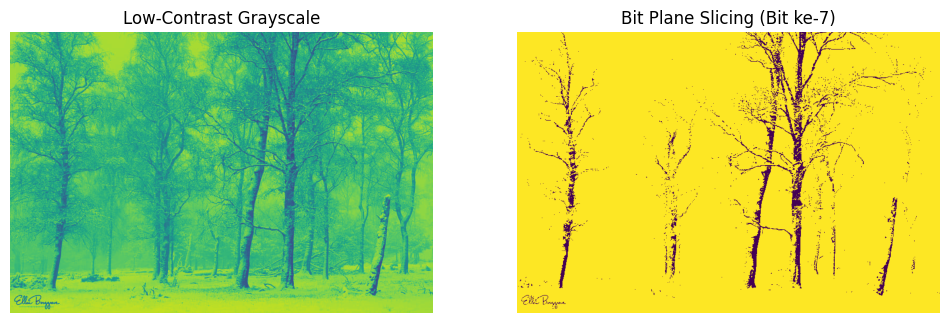

In [44]:
gray_bitplane = cv2.cvtColor(img_contrast, cv2.COLOR_RGB2GRAY)

bit_plane = ((gray_bitplane >> 7) & 1) * 255
bit_plane = bit_plane.astype(np.uint8)

tampilkan_perbandingan(
    gray_bitplane,
    bit_plane,
    "Low-Contrast Grayscale",
    "Bit Plane Slicing (Bit ke-7)"
)

In [45]:
img_blur = dataset["blur"]["images"][0]

print("Ukuran gambar:", img_blur.shape)

Ukuran gambar: (256, 256, 3)


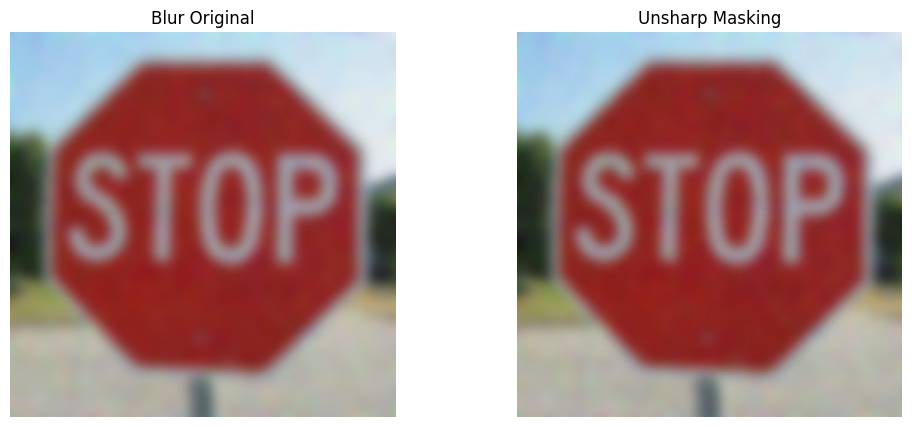

In [46]:
blur_float = img_blur.astype(np.float32)

gaussian_blur = cv2.GaussianBlur(blur_float, (5, 5), 0)

unsharp_blur = cv2.addWeighted(
    blur_float, 1.5,
    gaussian_blur, -0.5,
    0
)

unsharp_blur = np.clip(unsharp_blur, 0, 255).astype(np.uint8)

tampilkan_perbandingan(
    img_blur,
    unsharp_blur,
    "Blur Original",
    "Unsharp Masking"
)

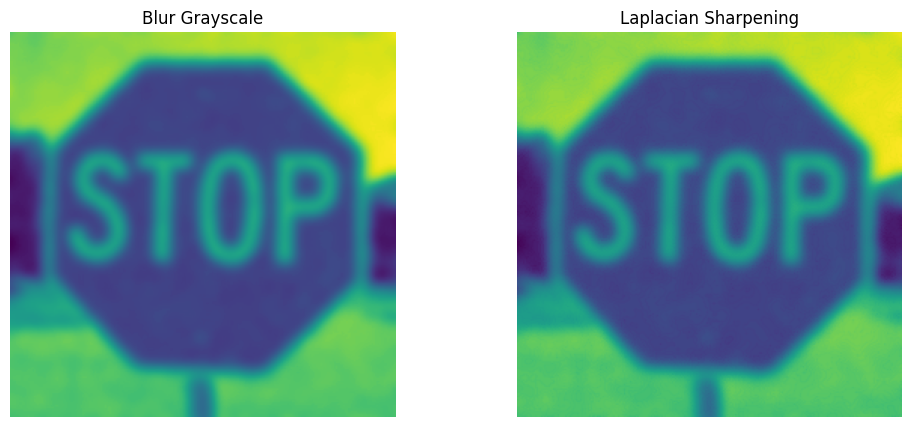

In [47]:
gray_blur = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)

laplacian = cv2.Laplacian(gray_blur, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

laplacian_sharp = cv2.addWeighted(
    gray_blur, 1,
    laplacian, -1,
    0
)

tampilkan_perbandingan(
    gray_blur,
    laplacian_sharp,
    "Blur Grayscale",
    "Laplacian Sharpening"
)

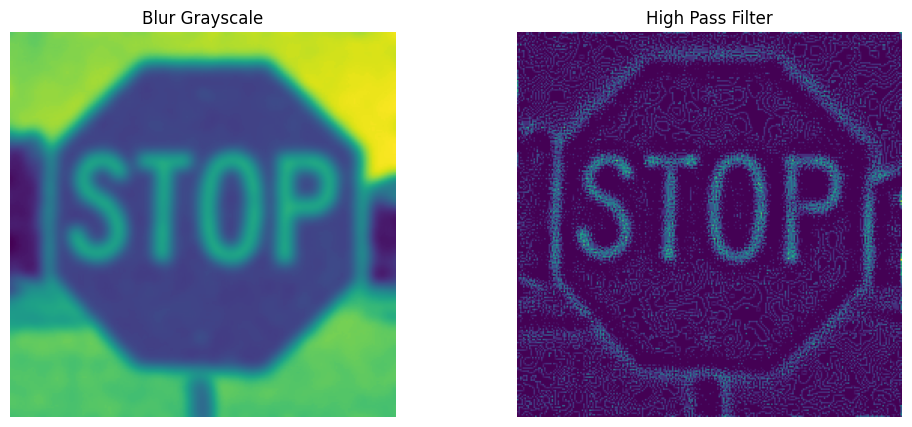

In [48]:
gray_blur = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)

kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

highpass_blur = cv2.filter2D(gray_blur, -1, kernel)

tampilkan_perbandingan(
    gray_blur,
    highpass_blur,
    "Blur Grayscale",
    "High Pass Filter"
)

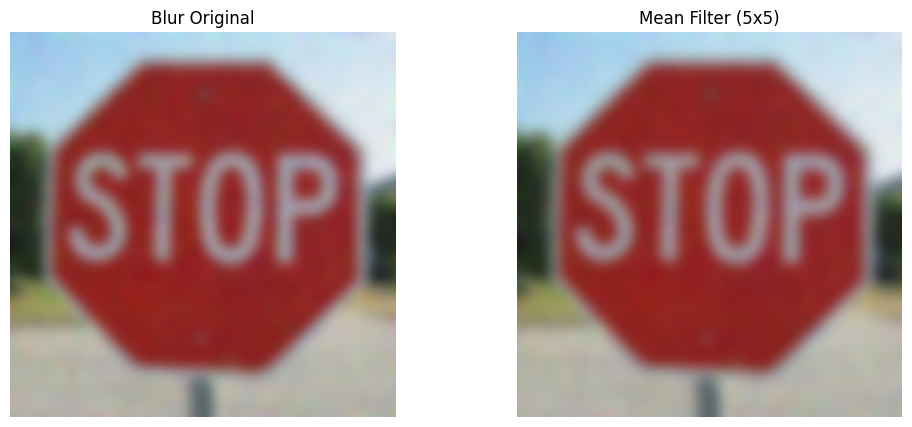

In [49]:
mean_blur = cv2.blur(img_blur, (5, 5))

tampilkan_perbandingan(
    img_blur,
    mean_blur,
    "Blur Original",
    "Mean Filter (5x5)"
)

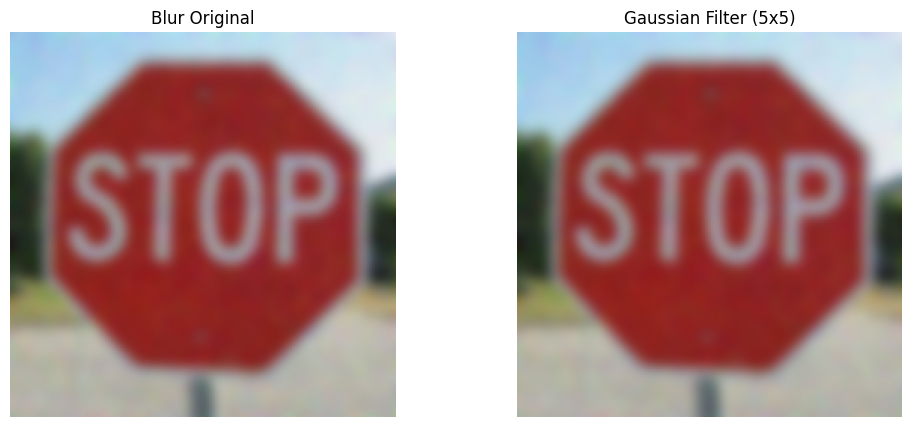

In [50]:
gaussian_blur = cv2.GaussianBlur(img_blur, (5, 5), 0)

tampilkan_perbandingan(
    img_blur,
    gaussian_blur,
    "Blur Original",
    "Gaussian Filter (5x5)"
)

In [51]:
img_noisy = dataset["noisy"]["images"][0]

print("Ukuran gambar:", img_noisy.shape)

Ukuran gambar: (399, 600, 3)


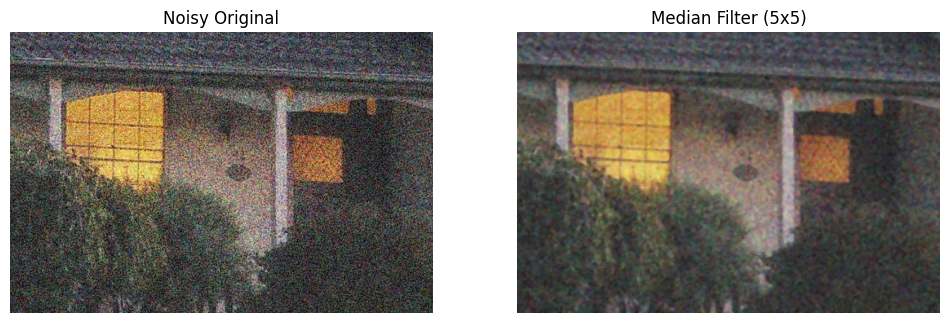

In [52]:
median_noisy = cv2.medianBlur(img_noisy, 5)

tampilkan_perbandingan(
    img_noisy,
    median_noisy,
    "Noisy Original",
    "Median Filter (5x5)"
)

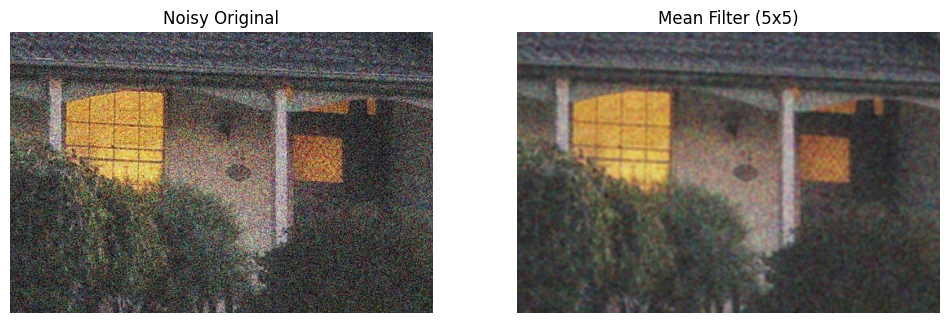

In [53]:
mean_noisy = cv2.blur(img_noisy, (5, 5))

tampilkan_perbandingan(
    img_noisy,
    mean_noisy,
    "Noisy Original",
    "Mean Filter (5x5)"
)

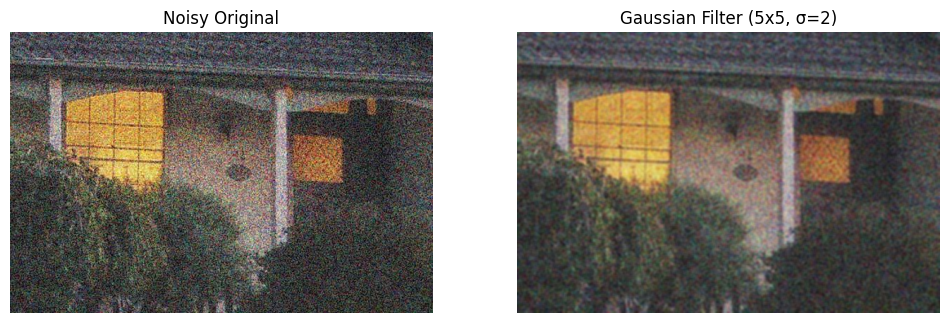

In [54]:
gaussian_noisy = cv2.GaussianBlur(img_noisy, (5, 5), 2)

tampilkan_perbandingan(
    img_noisy,
    gaussian_noisy,
    "Noisy Original",
    "Gaussian Filter (5x5, σ=2)"
)

In [55]:
for kategori in kategori_list:
    print(f"{kategori}: {len(dataset[kategori]['images'])} gambar")

low-light-image: 1 gambar
over-exposed: 1 gambar
low-contrast: 1 gambar
blur: 1 gambar
noisy: 1 gambar


In [56]:
for kategori in kategori_list:
    img = dataset[kategori]["images"][0]

    print(
        f"{kategori}: "
        f"min = {img.min()}, "
        f"max = {img.max()}"
    )

low-light-image: min = 0, max = 255
over-exposed: min = 0, max = 255
low-contrast: min = 21, max = 255
blur: min = 18, max = 245
noisy: min = 0, max = 255


In [57]:
for kategori in kategori_list:
    img = dataset[kategori]["images"][0]

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    print(
        f"{kategori}: "
        f"mean intensitas = {gray.mean():.2f}"
    )

low-light-image: mean intensitas = 56.69
over-exposed: mean intensitas = 239.32
low-contrast: mean intensitas = 180.08
blur: mean intensitas = 126.17
noisy: mean intensitas = 83.06


In [58]:
for kategori in kategori_list:
    img = dataset[kategori]["images"][0]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    print(
        f"{kategori}: "
        f"std = {gray.std():.2f}"
    )

low-light-image: std = 36.29
over-exposed: std = 21.08
low-contrast: std = 28.51
blur: std = 55.52
noisy: std = 41.33


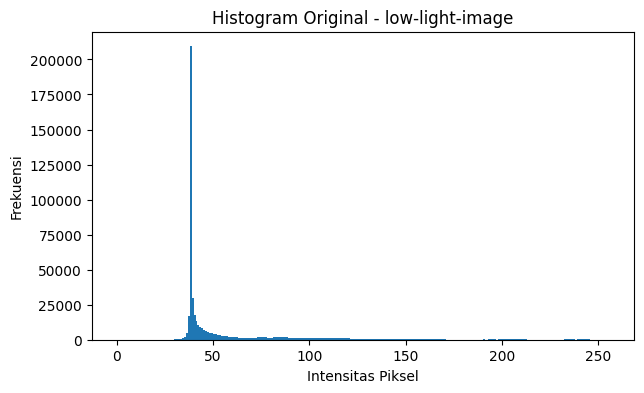

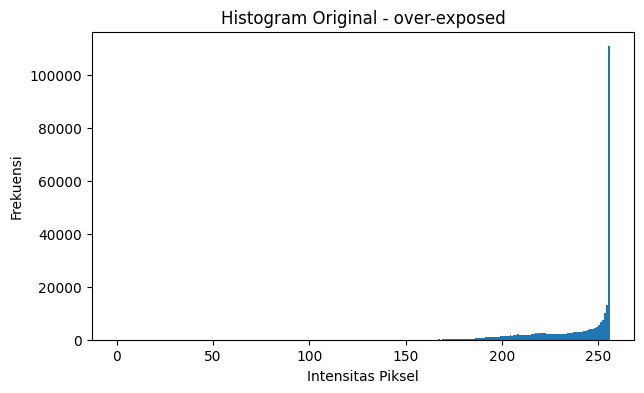

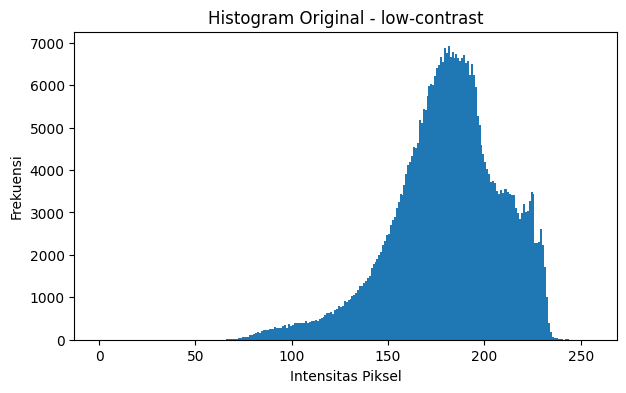

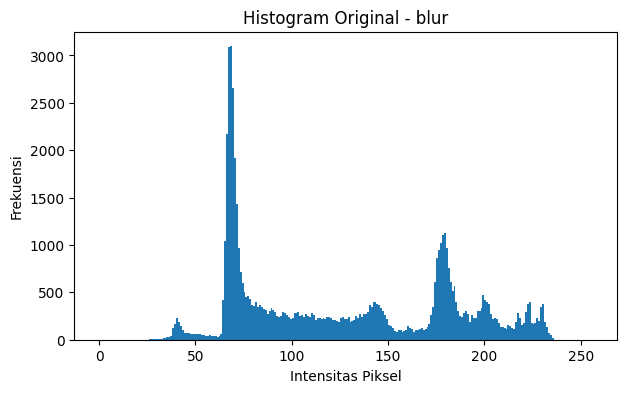

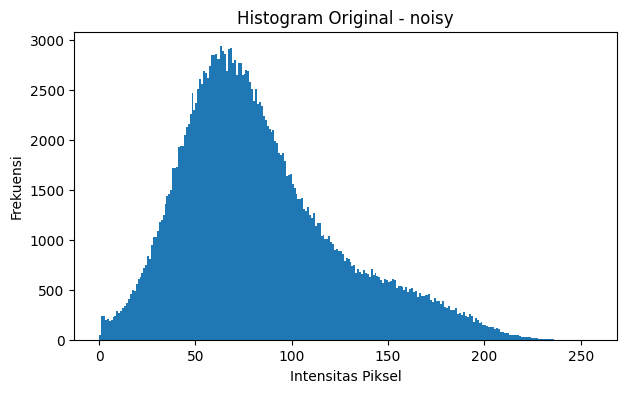

In [59]:
for kategori in kategori_list:
    img = dataset[kategori]["images"][0]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    plt.figure(figsize=(7, 4))
    plt.hist(gray.ravel(), bins=256, range=[0, 256])
    plt.title(f"Histogram Original - {kategori}")
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Frekuensi")
    plt.show()